In [48]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import cv2

# Download Dataset

In [ ]:
import kagglehub
current_dir = os.getcwd()

# Download dataset into current directory
path = kagglehub.dataset_download("ihelon/lego-minifigures-classification")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Omar Ben Emad\.cache\kagglehub\datasets\ihelon\lego-minifigures-classification\versions\30


# Data

In [62]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator
# for augmentating the data use the below
# train_data = ImageDataGenerator(rescale=1./255 , rotation_range=20 , horizontal_flip=True , zoom_range=0.2 , width_shift_range=0.2 , height_shift_range=0.2)
train_data = ImageDataGenerator(rescale=1./255)
valid_data = ImageDataGenerator(rescale=1./255)
test_data = ImageDataGenerator(rescale=1./255)

train_batch = train_data.flow_from_directory(
    directory=r"F:\Omar 3amora\حنكشة projects\Tensforflow Practice\lego-minifigures-classification\train",
    target_size=(256, 256),
    batch_size=4,
    class_mode="sparse",
    shuffle=True,
    color_mode="rgb"
    
)

validation_batch = valid_data.flow_from_directory(
    directory=r"F:\Omar 3amora\حنكشة projects\Tensforflow Practice\lego-minifigures-classification\valid",
    target_size=(256, 256),
    batch_size=4,
    class_mode="sparse",
    shuffle=True,
    color_mode="rgb"
)

test_batch = test_data.flow_from_directory(
    directory=r"F:\Omar 3amora\حنكشة projects\Tensforflow Practice\lego-minifigures-classification\test",
    target_size=(256, 256),
    batch_size=2,
    class_mode="sparse",
    color_mode="rgb",
)



Found 123 images belonging to 17 classes.


Found 59 images belonging to 17 classes.
Found 35 images belonging to 17 classes.


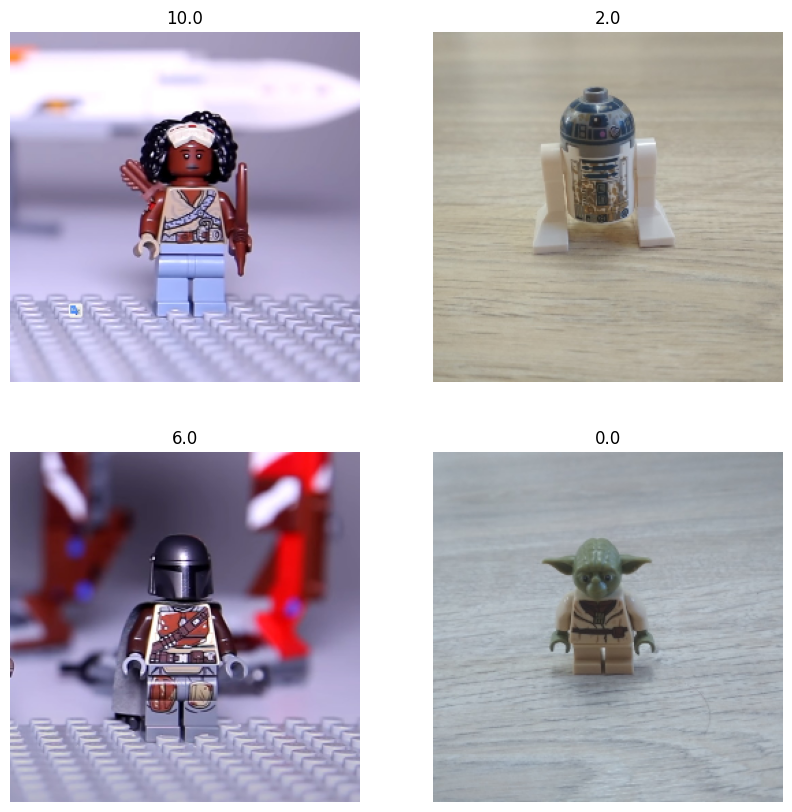

In [50]:
def show_batch_images(image_batch, label_batch):
    plt.figure(figsize=(10, 10))
    for i in range(4):
        ax = plt.subplot(2, 2, i + 1)
        plt.imshow(image_batch[i])
        plt.title(label_batch[i])
        plt.axis("off")
    plt.show()
show_batch_images(train_batch[0][0], train_batch[0][1])

# Model

In [51]:
model = keras.Sequential()
model.add(layers.Conv2D(32, (3, 3), strides=(1,1),padding='valid' ,activation="relu", input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), strides=(1,1),padding='valid' ,activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), strides=(1,1),padding='valid' ,activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation="relu"))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(17))
print(model.summary())

c:\Users\Omar Ben Emad\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,337 (56.64 MB)

 Trainable params: 14,848,337 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

None


In [67]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',   # what to watch
    patience=10,           # wait 5 epochs before stopping
    restore_best_weights=True  # go back to best model
)

loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = keras.optimizers.Adam(learning_rate=0.001)
metrics = ["accuracy"]
model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
epochs = 50
history = model.fit(train_batch, epochs=epochs, validation_data=validation_batch, callbacks=[early_stop])

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - accuracy: 0.8780 - loss: 0.5252 - val_accuracy: 0.6102 - val_loss: 2.4706
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - accuracy: 0.9593 - loss: 0.2288 - val_accuracy: 0.6271 - val_loss: 3.6573
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.9512 - loss: 0.2333 - val_accuracy: 0.6441 - val_loss: 2.1742
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.9837 - loss: 0.0588 - val_accuracy: 0.6271 - val_loss: 4.0360
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 1.0000 - loss: 0.0140 - val_accuracy: 0.6441 - val_loss: 4.4775
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.9512 - loss: 0.1704 - val_accuracy: 0.6780 - val_loss: 1.9859
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - accuracy: 0.9919 - loss: 0.0694 - val_accuracy: 0.6610 - val_loss: 3.1988
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 237ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 0

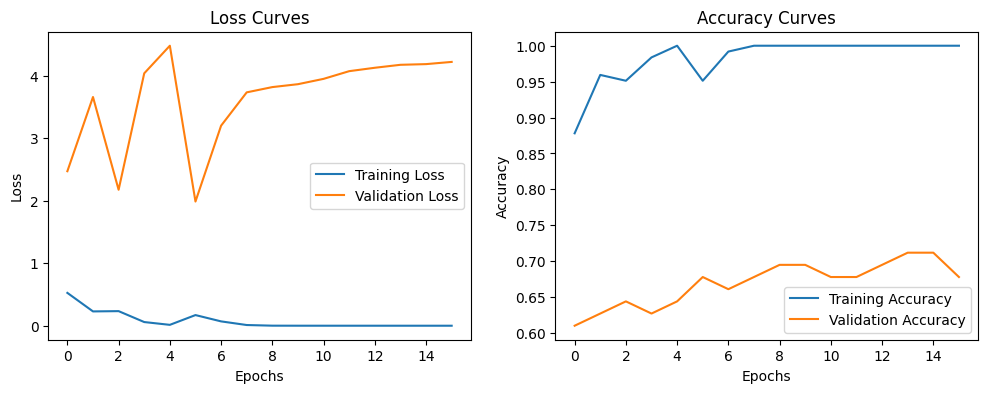

In [68]:
# Plot loss and accuracy curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [69]:
print(test_batch.class_indices)
print(test_batch.samples)
print(test_batch.num_classes)

{'0001': 0, '0002': 1, '0003': 2, '0004': 3, '0005': 4, '0006': 5, '0007': 6, '0008': 7, '0009': 8, '0010': 9, '0011': 10, '0012': 11, '0013': 12, '0014': 13, '0015': 14, '0016': 15, '0017': 16}
35
17


In [70]:
eval_loss, eval_acc = model.evaluate(
    test_batch,
    steps=len(test_batch),
    verbose=1
)
print(f"Test Loss: {eval_loss:.4f}, Test Accuracy: {eval_acc:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4286 - loss: 5.5751
Test Loss: 5.5751, Test Accuracy: 0.4286


**Predcition**

In [71]:
pred = model.predict(test_batch)
for i in range(18):
    print(f"Predicted: {np.argmax(pred[i])}, Actual: {test_batch.labels[i]}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted: 9, Actual: 0
Predicted: 0, Actual: 0
Predicted: 13, Actual: 1
Predicted: 11, Actual: 1
Predicted: 11, Actual: 2
Predicted: 4, Actual: 2
Predicted: 13, Actual: 3
Predicted: 13, Actual: 3
Predicted: 14, Actual: 4
Predicted: 3, Actual: 4
Predicted: 0, Actual: 5
Predicted: 8, Actual: 5
Predicted: 2, Actual: 6
Predicted: 14, Actual: 7
Predicted: 12, Actual: 8
Predicted: 3, Actual: 9
Predicted: 3, Actual: 10
Predicted: 10, Actual: 10
